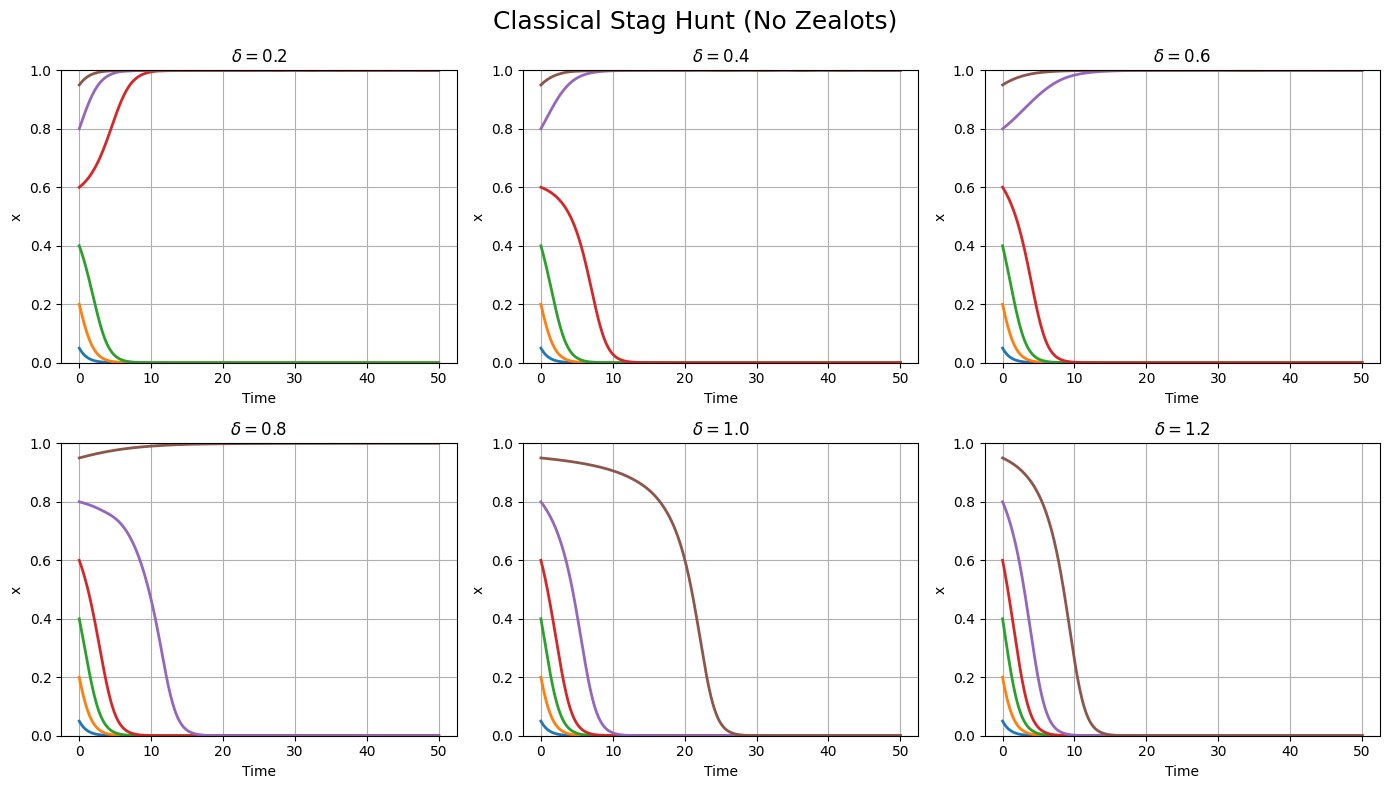

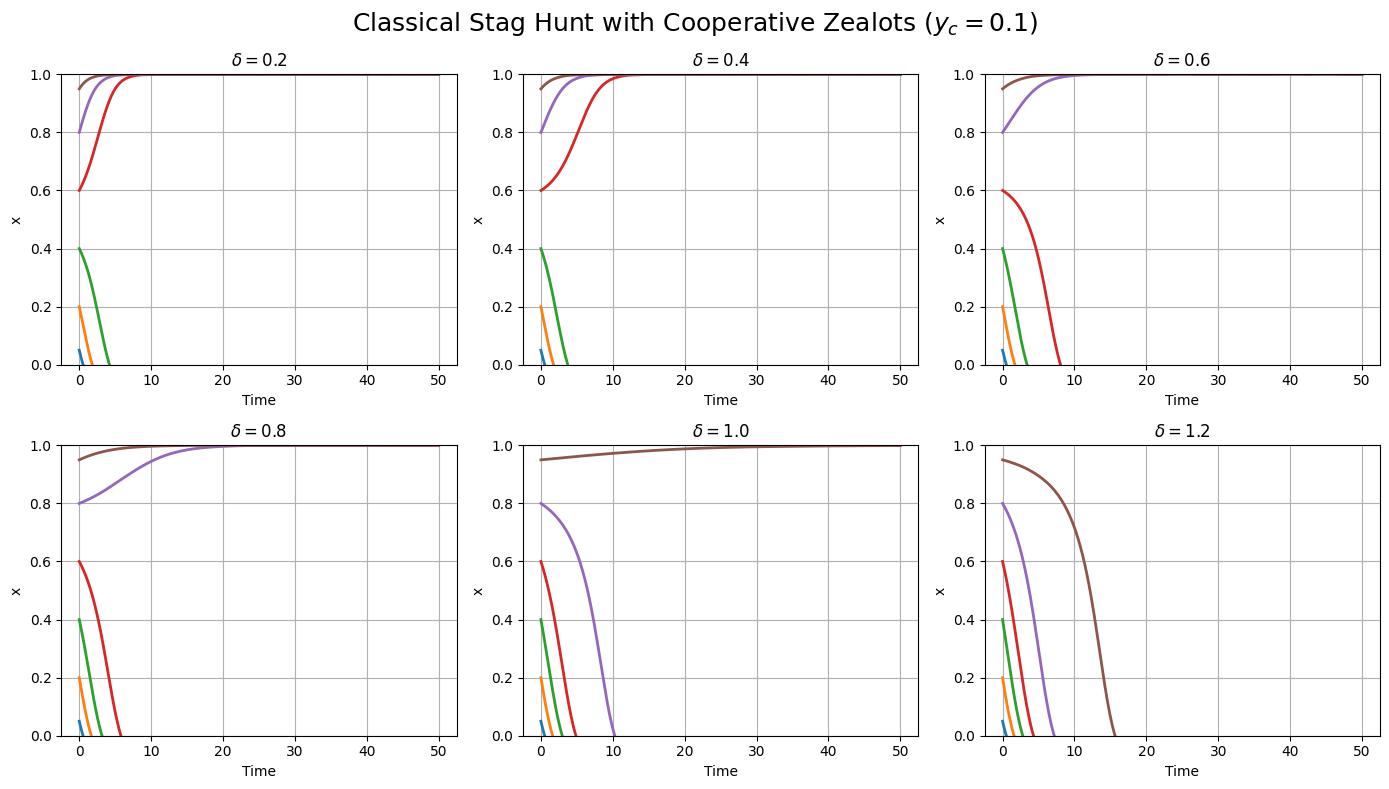

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================
# PARAMETERS
# ============================================

delta_values = [0.2,0.4,0.6,0.8,1.0,1.2]

t_span = (0,50)
t_eval = np.linspace(0,50,500)

initial_conditions = [0.05,0.2,0.4,0.6,0.8,0.95]

# ======================================================
# STANDARD STAG HUNT (NO ZEALOTS)
# ======================================================

fig,axs=plt.subplots(2,3,figsize=(14,8))

for k,delta in enumerate(delta_values):

    ax=axs[k//3,k%3]

    R=1
    S=-1
    T=delta
    P=0

    def replicator(t,x):

        x=x[0]

        piC=x*R+(1-x)*S
        piD=x*T+(1-x)*P

        dx=x*(1-x)*(piC-piD)

        return [dx]

    for x0 in initial_conditions:

        sol=solve_ivp(replicator,
                      t_span,
                      [x0],
                      t_eval=t_eval)

        ax.plot(sol.t,sol.y[0],lw=2,label=f'{x0}')

    ax.set_title(r'$\delta={}$'.format(delta))
    ax.set_xlabel('Time')
    ax.set_ylabel('x')
    ax.grid(True)
    ax.set_ylim(0,1)

plt.suptitle('Classical Stag Hunt (No Zealots)',fontsize=18)
plt.tight_layout()
plt.show()


# ======================================================
# STAG HUNT WITH COOPERATIVE ZEALOTS
# ======================================================

yc=0.1

fig,axs=plt.subplots(2,3,figsize=(14,8))

for k,delta in enumerate(delta_values):

    ax=axs[k//3,k%3]

    R=1
    S=-1
    T=delta
    P=0

    def zealot(t,x):

        x=x[0]

        piC=((x+yc)*R+(1-x)*S)/(1+yc)
        piD=((x+yc)*T+(1-x)*P)/(1+yc)

        dx=((x+yc)*piC*(1-x)
            -(1-x)*piD*x)

        return [dx]

    for x0 in initial_conditions:

        sol=solve_ivp(zealot,
                      t_span,
                      [x0],
                      t_eval=t_eval)

        ax.plot(sol.t,sol.y[0],lw=2,label=f'{x0}')

    ax.set_title(r'$\delta={}$'.format(delta))
    ax.set_xlabel('Time')
    ax.set_ylabel('x')
    ax.grid(True)
    ax.set_ylim(0,1)

plt.suptitle('Classical Stag Hunt with Cooperative Zealots ($y_c=0.1$)',fontsize=18)
plt.tight_layout()
plt.show()

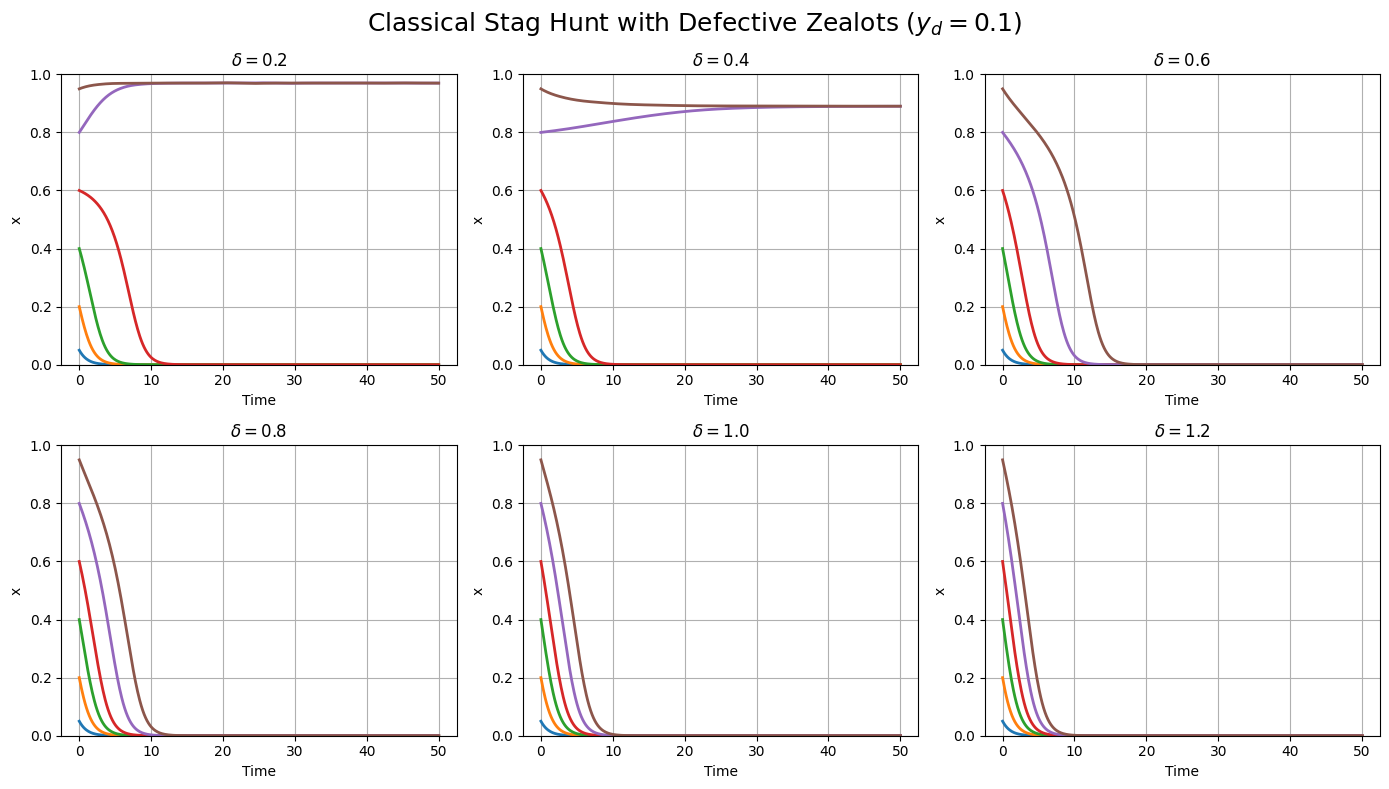

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================
# PARAMETERS
# ============================================

delta_values = [0.2,0.4,0.6,0.8,1.0,1.2]

yd = 0.1                # Defective zealots

t_span = (0,50)
t_eval = np.linspace(0,50,500)

initial_conditions = [0.05,0.2,0.4,0.6,0.8,0.95]

# ======================================================
# STAG HUNT WITH DEFECTIVE ZEALOTS
# (NON-NORMALIZED)
# ======================================================

fig,axs = plt.subplots(2,3,figsize=(14,8))

for k,delta in enumerate(delta_values):

    ax = axs[k//3,k%3]

    R = 1
    S = -1
    T = delta
    P = 0

    def defectors(t,x):

        x = x[0]

        # Expected payoffs
        piC = (x*R + (1-x+yd)*S)/(1+yd)
        piD = (x*T + (1-x+yd)*P)/(1+yd)

        # Non-normalized dynamics
        dx = (x*piC*(1-x)
              -(1-x+yd)*piD*x)

        return [dx]

    for x0 in initial_conditions:

        sol = solve_ivp(defectors,
                        t_span,
                        [x0],
                        t_eval=t_eval)

        ax.plot(sol.t,
                sol.y[0],
                lw=2,
                label=f'{x0}')

    ax.set_title(r'$\delta={}$'.format(delta))
    ax.set_xlabel("Time")
    ax.set_ylabel("x")
    ax.set_ylim(0,1)
    ax.grid(True)

plt.suptitle("Classical Stag Hunt with Defective Zealots ($y_d=0.1$)",fontsize=18)
plt.tight_layout()
plt.show()

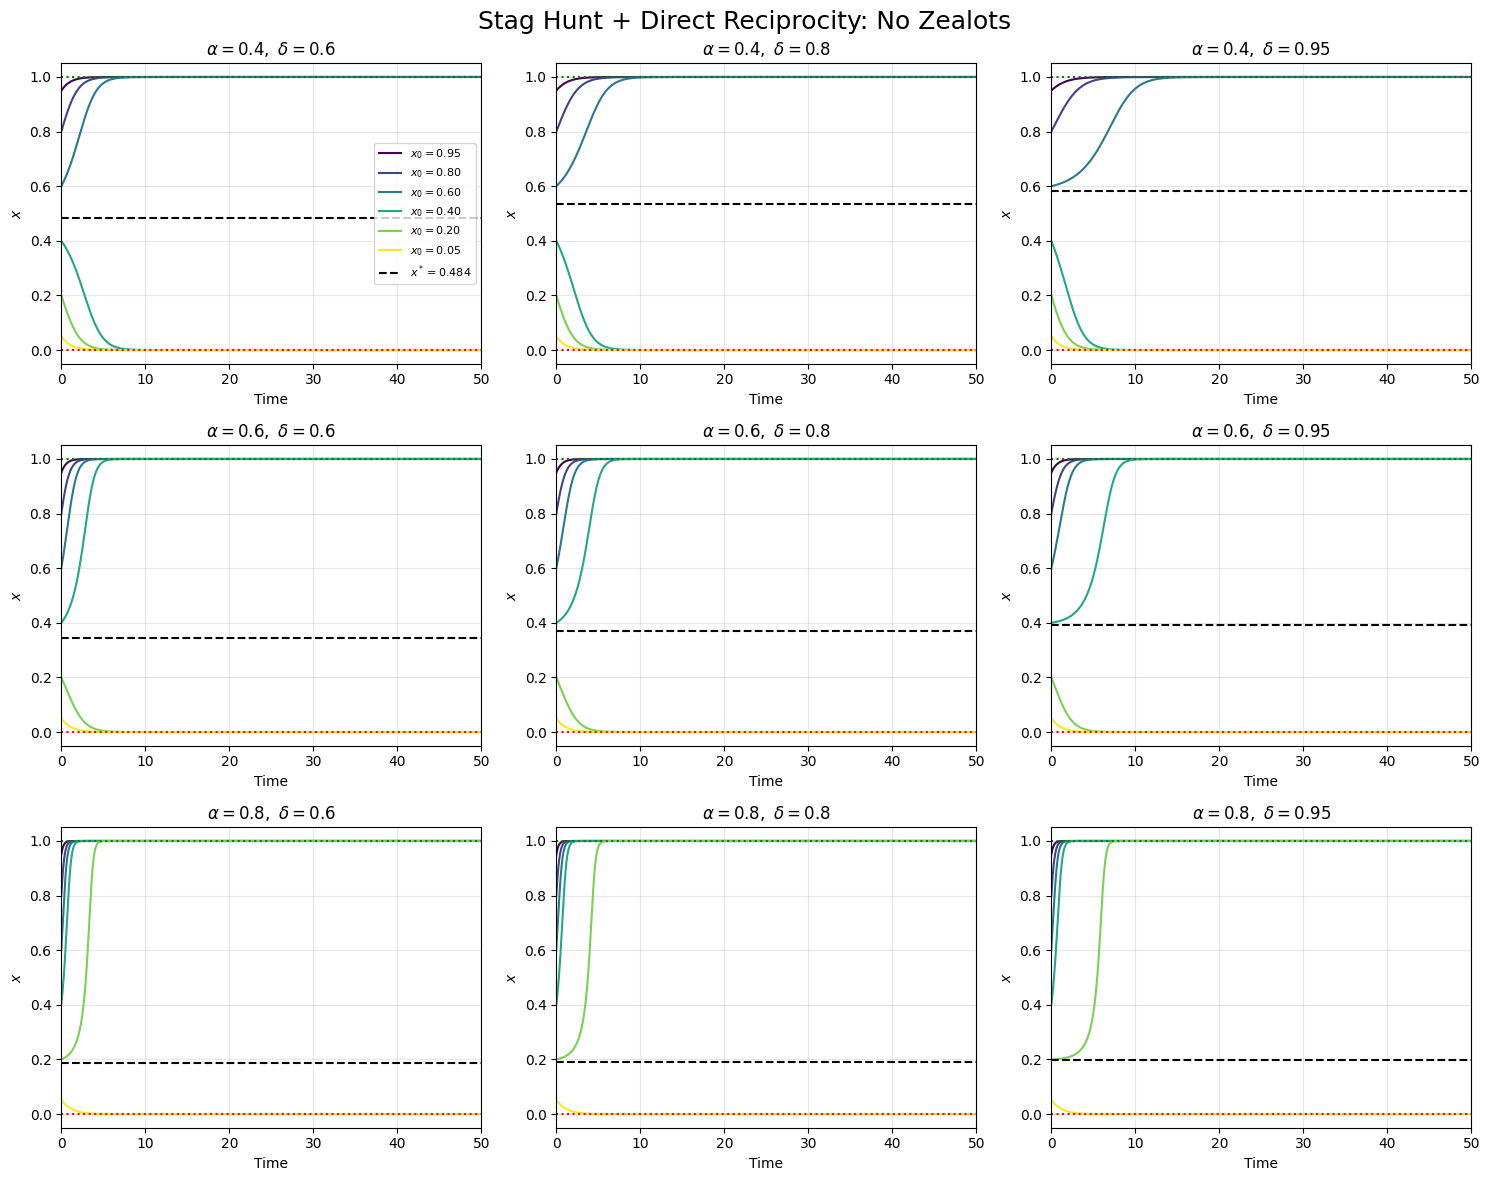

C:\Users\ASUS\AppData\Local\Temp\ipykernel_35216\2347687570.py:106: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(


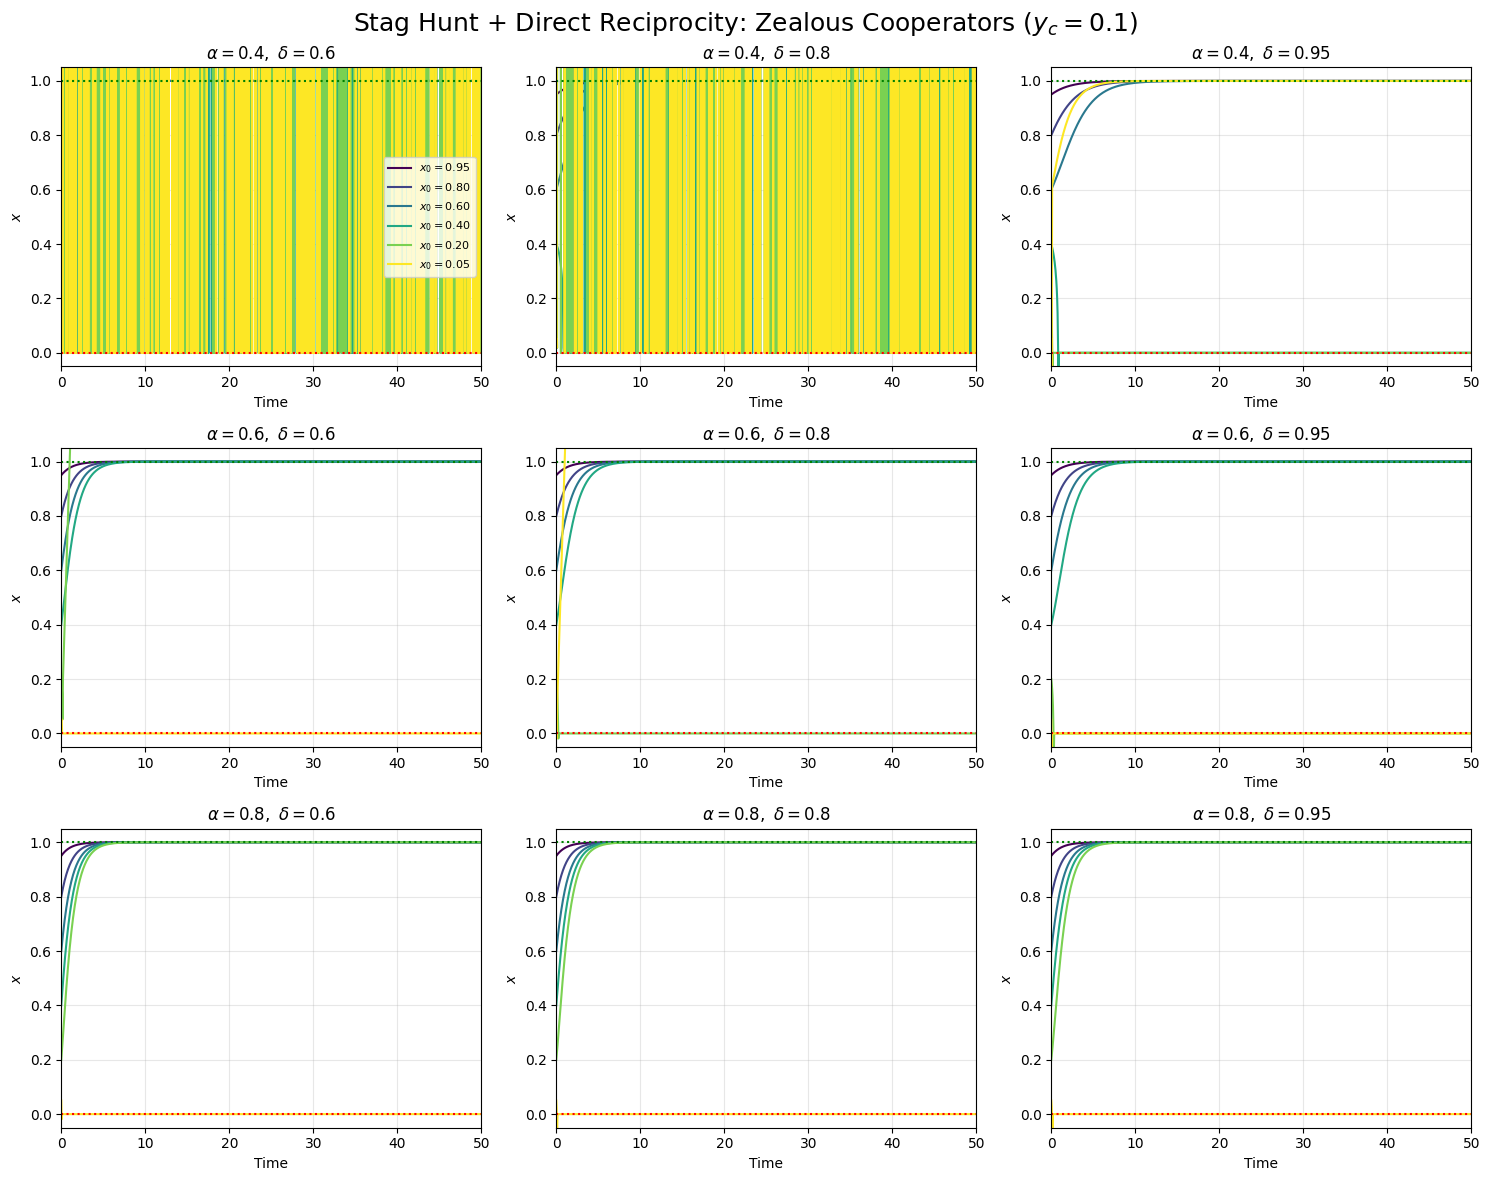


===== PARAMETER SUMMARY =====
Zealous cooperators yc = 0.1
alpha values = [0.4, 0.6, 0.8]
delta values = [0.6, 0.8, 0.95]

Interior equilibrium (No Zealots):
alpha=0.4, delta=0.60 -> x* = 0.4839
alpha=0.4, delta=0.80 -> x* = 0.5357
alpha=0.4, delta=0.95 -> x* = 0.5825
alpha=0.6, delta=0.60 -> x* = 0.3448
alpha=0.6, delta=0.80 -> x* = 0.3704
alpha=0.6, delta=0.95 -> x* = 0.3922
alpha=0.8, delta=0.60 -> x* = 0.1852
alpha=0.8, delta=0.80 -> x* = 0.1923
alpha=0.8, delta=0.95 -> x* = 0.1980


In [14]:
# ---------- PARAMETERS ----------
alpha_values = [0.4, 0.6, 0.8]
delta_values = [0.6, 0.8, 0.95]
yc = 0.1

# ---------- INITIAL CONDITIONS ----------
x0_list = [0.95, 0.80, 0.60, 0.40, 0.20, 0.05]

# ---------- TIME ----------
tspan = np.linspace(0, 50, 1000)

# =========================================================
# ODE FUNCTIONS
# =========================================================

def no_zealot(x, t, alpha, delta):
    R_tilde = 1/(1-alpha)
    return x*(1-x)*(-1 + x*(R_tilde + 1 - delta))


def zealot_C(x, t, alpha, delta, yc):
    R_tilde = 1/(1-alpha)

    numerator = (1-x)*((x+yc)*R_tilde - 1 + x*(1-delta))
    denominator = (x+yc)*R_tilde + (1-x)*(delta-1)

    return numerator/denominator


# =========================================================
# 1. NO ZEALOTS
# =========================================================

fig1, axes1 = plt.subplots(3,3,figsize=(15,12))
fig1.suptitle("Stag Hunt + Direct Reciprocity: No Zealots",
              fontsize=18)

colors = plt.cm.viridis(np.linspace(0,1,len(x0_list)))

for i, alpha in enumerate(alpha_values):

    for j, delta in enumerate(delta_values):

        ax = axes1[i,j]

        R_tilde = 1/(1-alpha)

        for k,x0 in enumerate(x0_list):

            sol = odeint(no_zealot,x0,tspan,args=(alpha,delta))

            ax.plot(
                tspan,
                sol,
                color=colors[k],
                lw=1.5,
                label=f"$x_0={x0:.2f}$"
            )

        x_star = 1/(R_tilde+1-delta)

        if 0<x_star<1:
            ax.axhline(
                x_star,
                color='k',
                ls='--',
                lw=1.5,
                label=f"$x^*={x_star:.3f}$"
            )

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$\alpha={alpha},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.set_xlabel("Time")
        ax.set_ylabel("$x$")
        ax.grid(alpha=0.3)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# =========================================================
# 2. ZEALOUS COOPERATORS
# =========================================================

fig2, axes2 = plt.subplots(3,3,figsize=(15,12))
fig2.suptitle(
    f"Stag Hunt + Direct Reciprocity: Zealous Cooperators ($y_c={yc}$)",
    fontsize=18
)

for i, alpha in enumerate(alpha_values):

    for j, delta in enumerate(delta_values):

        ax = axes2[i,j]

        for k,x0 in enumerate(x0_list):

            sol = odeint(
                zealot_C,
                x0,
                tspan,
                args=(alpha,delta,yc)
            )

            ax.plot(
                tspan,
                sol,
                color=colors[k],
                lw=1.5,
                label=f"$x_0={x0:.2f}$"
            )

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$\alpha={alpha},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.set_xlabel("Time")
        ax.set_ylabel("$x$")
        ax.grid(alpha=0.3)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# =========================================================
# PARAMETER SUMMARY
# =========================================================

print("\n===== PARAMETER SUMMARY =====")
print(f"Zealous cooperators yc = {yc}")
print(f"alpha values = {alpha_values}")
print(f"delta values = {delta_values}")

print("\nInterior equilibrium (No Zealots):")

for alpha in alpha_values:

    R_tilde = 1/(1-alpha)

    for delta in delta_values:

        x_star = 1/(R_tilde+1-delta)

        print(
            f"alpha={alpha:.1f}, delta={delta:.2f} -> x* = {x_star:.4f}"
        )

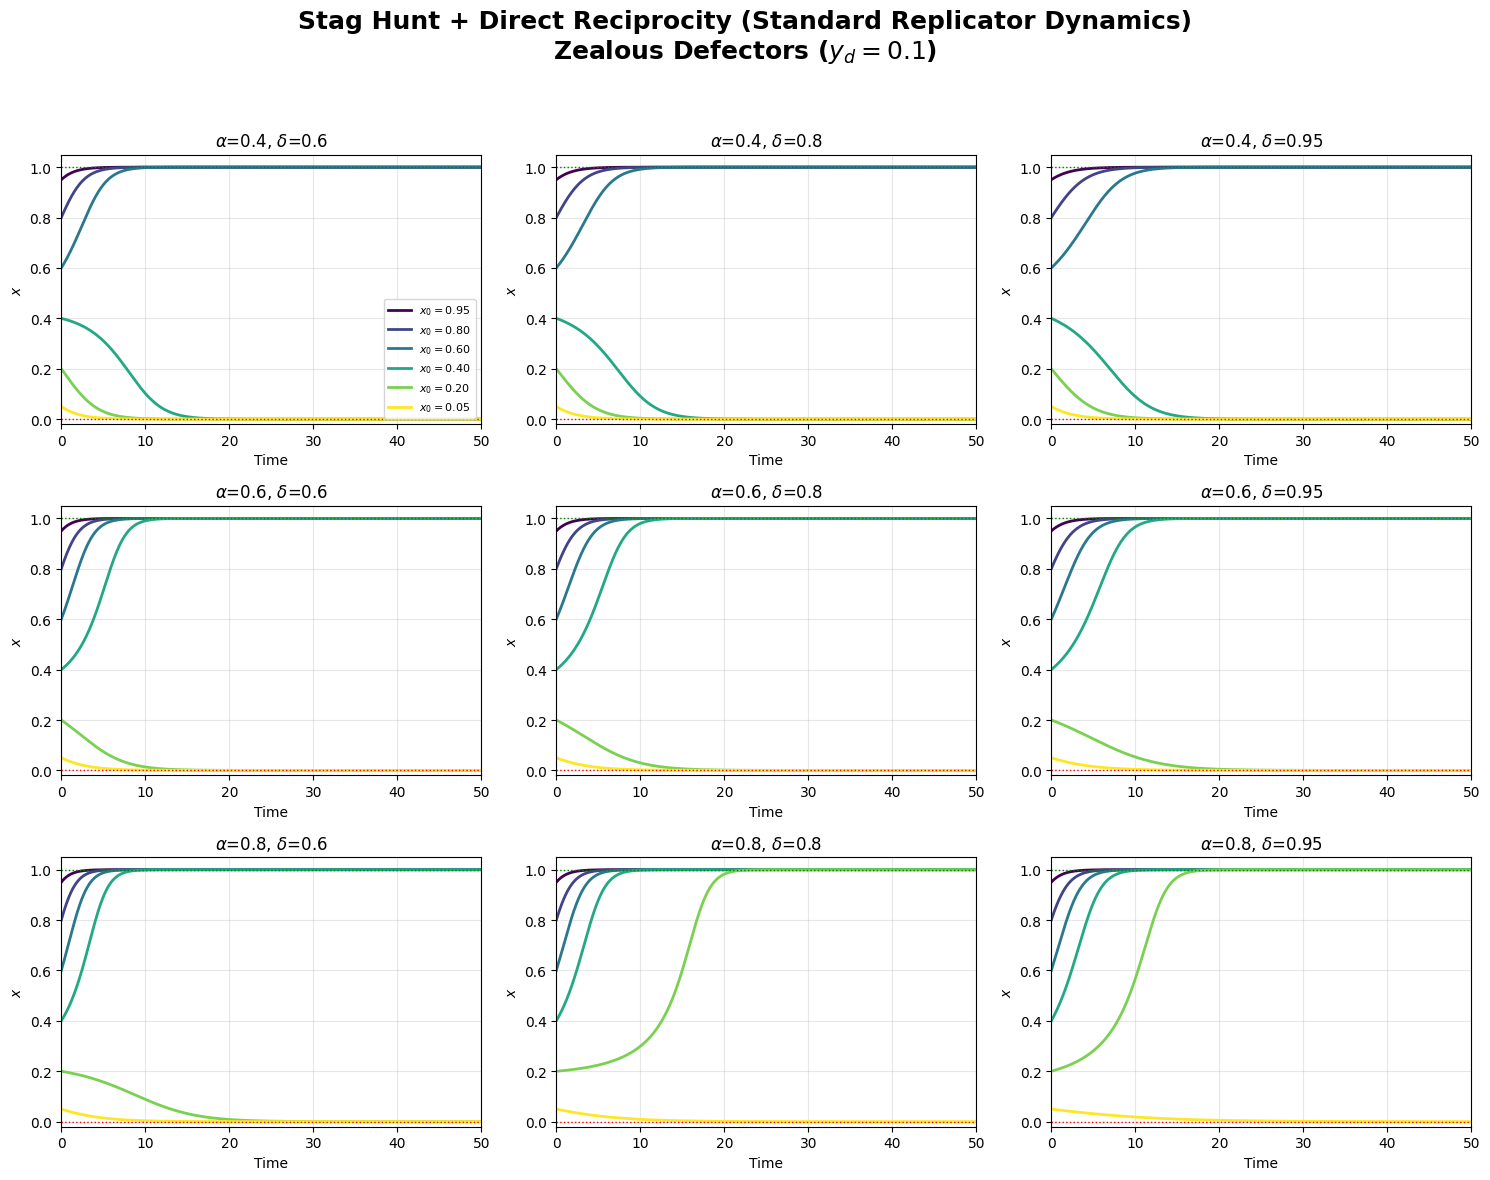

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# STAG HUNT + DIRECT RECIPROCITY
# STANDARD REPLICATOR DYNAMICS (WITHOUT NORMALIZATION)
#
# dx/dt = x(1-x)(piC-piD)
#
# Zealous Defectors
# ============================================================

# Parameters
yd = 0.10

alpha_values = [0.4, 0.6, 0.8]
delta_values = [0.6, 0.8, 0.95]

x0_list = [0.95, 0.80, 0.60, 0.40, 0.20, 0.05]

t_span = (0, 50)
t_eval = np.linspace(0, 50, 1000)

colors = plt.cm.viridis(np.linspace(0, 1, len(x0_list)))

# -------------------------------------------------------------
# Standard Replicator Equation
# -------------------------------------------------------------
def replicator(t, y, alpha, delta, yd):

    x = y[0]

    # Effective payoffs
    R = 1.0
    S = (alpha * delta - 1) / (1 + alpha)
    T = (delta - alpha) / (1 + alpha)
    P = 0.0

    # Fitnesses
    piC = (x * R + (1 - x + yd) * S) / (1 + yd)
    piD = (x * T + (1 - x + yd) * P) / (1 + yd)

    dx = x * (1 - x) * (piC - piD)

    return [dx]

# -------------------------------------------------------------
# Plot
# -------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, alpha in enumerate(alpha_values):

    for j, delta in enumerate(delta_values):

        ax = axes[i, j]

        for k, x0 in enumerate(x0_list):

            sol = solve_ivp(
                replicator,
                t_span,
                [x0],
                args=(alpha, delta, yd),
                t_eval=t_eval,
                rtol=1e-9,
                atol=1e-12
            )

            ax.plot(
                sol.t,
                sol.y[0],
                lw=2,
                color=colors[k],
                label=fr"$x_0={x0:.2f}$"
            )

        ax.axhline(0, color='red', ls=':', lw=1)
        ax.axhline(1, color='green', ls=':', lw=1)

        ax.set_xlim(0, 50)
        ax.set_ylim(-0.02, 1.05)

        ax.set_title(
            fr"$\alpha$={alpha}, $\delta$={delta}",
            fontsize=12
        )

        ax.set_xlabel("Time")
        ax.set_ylabel("$x$")
        ax.grid(alpha=0.3)

        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle(
    "Stag Hunt + Direct Reciprocity (Standard Replicator Dynamics)\n"
    "Zealous Defectors ($y_d=0.1$)",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

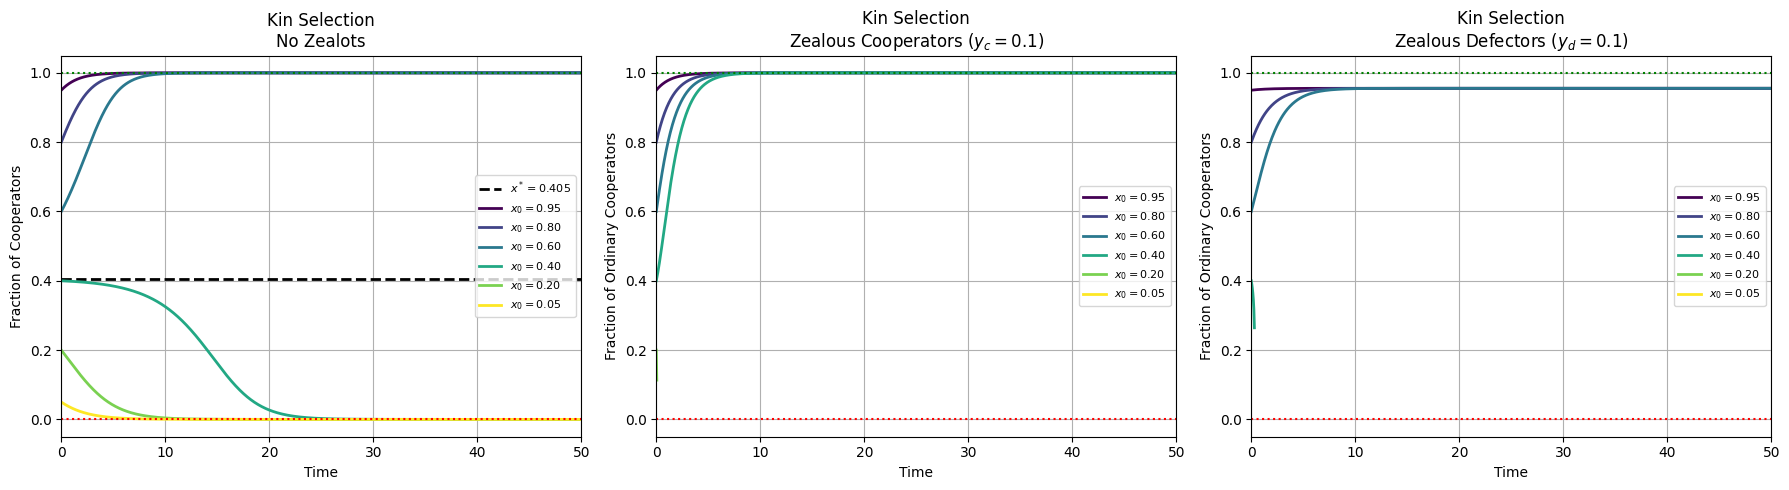


========== KIN SELECTION ==========
r = 0.4
delta = 0.8
S_tilde = -0.485714
S_tilde + T_tilde = -0.200000
Interior equilibrium x* = 0.404762


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =========================================================
# STAG HUNT + KIN SELECTION
# =========================================================

# ---------- PARAMETERS ----------
r = 0.4
delta = 0.8

yc = 0.10
yd = 0.10

S_tilde = (-1 + r*delta)/(1+r)
S_plus_T = delta - 1

tspan = (0,50)
t_eval = np.linspace(0,50,1000)

x0_list = [0.95,0.80,0.60,0.40,0.20,0.05]

# =========================================================
# REPLICATOR EQUATIONS
# =========================================================

# ---------- No Zealots ----------
def no_zealot(t,y):
    x = y[0]
    dx = x*(1-x)*(S_tilde + x*(2-delta))
    return [dx]

# ---------- Zealous Cooperators ----------
def zealot_C(t,y):
    x = y[0]

    num = (1-x)*((x+yc)+S_tilde-x*S_plus_T)
    den = (x+yc)+(1-x)*S_plus_T

    return [num/den]

# ---------- Zealous Defectors ----------
def zealot_D(t,y):
    x = y[0]

    num = (1-x)*x + (1-x+yd)*(S_tilde-x*S_plus_T)
    den = x+(1-x+yd)*S_plus_T

    return [num/den]

# =========================================================
# EVENTS (STOP IF DENOMINATOR = 0)
# =========================================================

def event_C(t,y):
    x=y[0]
    return (x+yc)+(1-x)*S_plus_T

event_C.terminal=True
event_C.direction=0

def event_D(t,y):
    x=y[0]
    return x+(1-x+yd)*S_plus_T

event_D.terminal=True
event_D.direction=0

# =========================================================
# FIGURE
# =========================================================

fig,axes=plt.subplots(1,3,figsize=(18,5))

colors=plt.cm.viridis(np.linspace(0,1,len(x0_list)))

# =========================================================
# PANEL 1
# =========================================================

ax=axes[0]

x_star=-S_tilde/(2-delta)

if 0<x_star<1:
    ax.axhline(x_star,color='k',ls='--',lw=2,
               label=fr'$x^*={x_star:.3f}$')

for i,x0 in enumerate(x0_list):

    sol=solve_ivp(no_zealot,
                  tspan,
                  [x0],
                  t_eval=t_eval,
                  rtol=1e-9,
                  atol=1e-12)

    ax.plot(sol.t,sol.y[0],
            lw=2,
            color=colors[i],
            label=fr'$x_0={x0:.2f}$')

ax.axhline(0,color='r',ls=':')
ax.axhline(1,color='g',ls=':')

ax.set_title('Kin Selection\nNo Zealots')
ax.set_xlabel('Time')
ax.set_ylabel('Fraction of Cooperators')
ax.set_xlim(tspan)
ax.set_ylim(-0.05,1.05)
ax.grid(True)
ax.legend(fontsize=8)

# =========================================================
# PANEL 2
# =========================================================

ax=axes[1]

for i,x0 in enumerate(x0_list):

    sol=solve_ivp(zealot_C,
                  tspan,
                  [x0],
                  t_eval=t_eval,
                  events=event_C,
                  rtol=1e-9,
                  atol=1e-12)

    ax.plot(sol.t,sol.y[0],
            lw=2,
            color=colors[i],
            label=fr'$x_0={x0:.2f}$')

ax.axhline(0,color='r',ls=':')
ax.axhline(1,color='g',ls=':')

ax.set_title(fr'Kin Selection'+'\n'+fr'Zealous Cooperators ($y_c={yc}$)')
ax.set_xlabel('Time')
ax.set_ylabel('Fraction of Ordinary Cooperators')
ax.set_xlim(tspan)
ax.set_ylim(-0.05,1.05)
ax.grid(True)
ax.legend(fontsize=8)

# =========================================================
# PANEL 3
# =========================================================

ax=axes[2]

for i,x0 in enumerate(x0_list):

    sol=solve_ivp(zealot_D,
                  tspan,
                  [x0],
                  t_eval=t_eval,
                  events=event_D,
                  rtol=1e-9,
                  atol=1e-12)

    ax.plot(sol.t,sol.y[0],
            lw=2,
            color=colors[i],
            label=fr'$x_0={x0:.2f}$')

ax.axhline(0,color='r',ls=':')
ax.axhline(1,color='g',ls=':')

ax.set_title(fr'Kin Selection'+'\n'+fr'Zealous Defectors ($y_d={yd}$)')
ax.set_xlabel('Time')
ax.set_ylabel('Fraction of Ordinary Cooperators')
ax.set_xlim(tspan)
ax.set_ylim(-0.05,1.05)
ax.grid(True)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# =========================================================
# EQUILIBRIUM INFORMATION
# =========================================================

print("\n========== KIN SELECTION ==========")
print(f"r = {r}")
print(f"delta = {delta}")
print(f"S_tilde = {S_tilde:.6f}")
print(f"S_tilde + T_tilde = {S_plus_T:.6f}")

if 0 < x_star < 1:
    print(f"Interior equilibrium x* = {x_star:.6f}")
else:
    print("No interior equilibrium.")

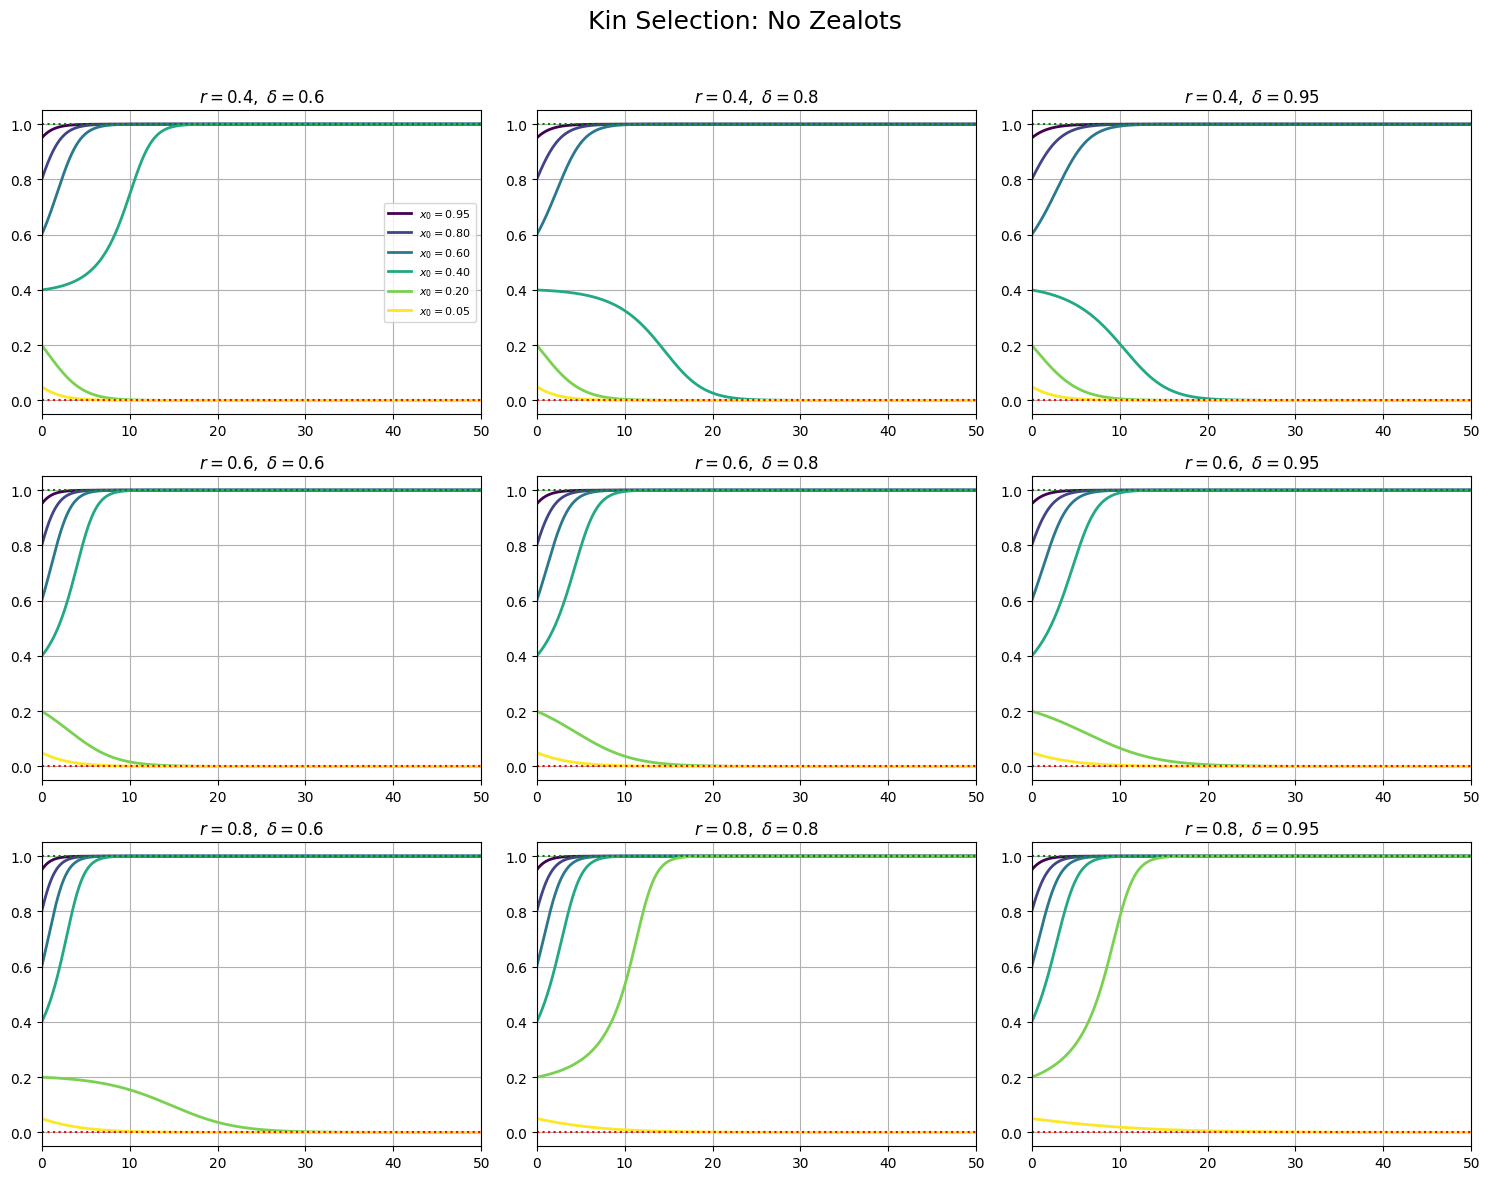

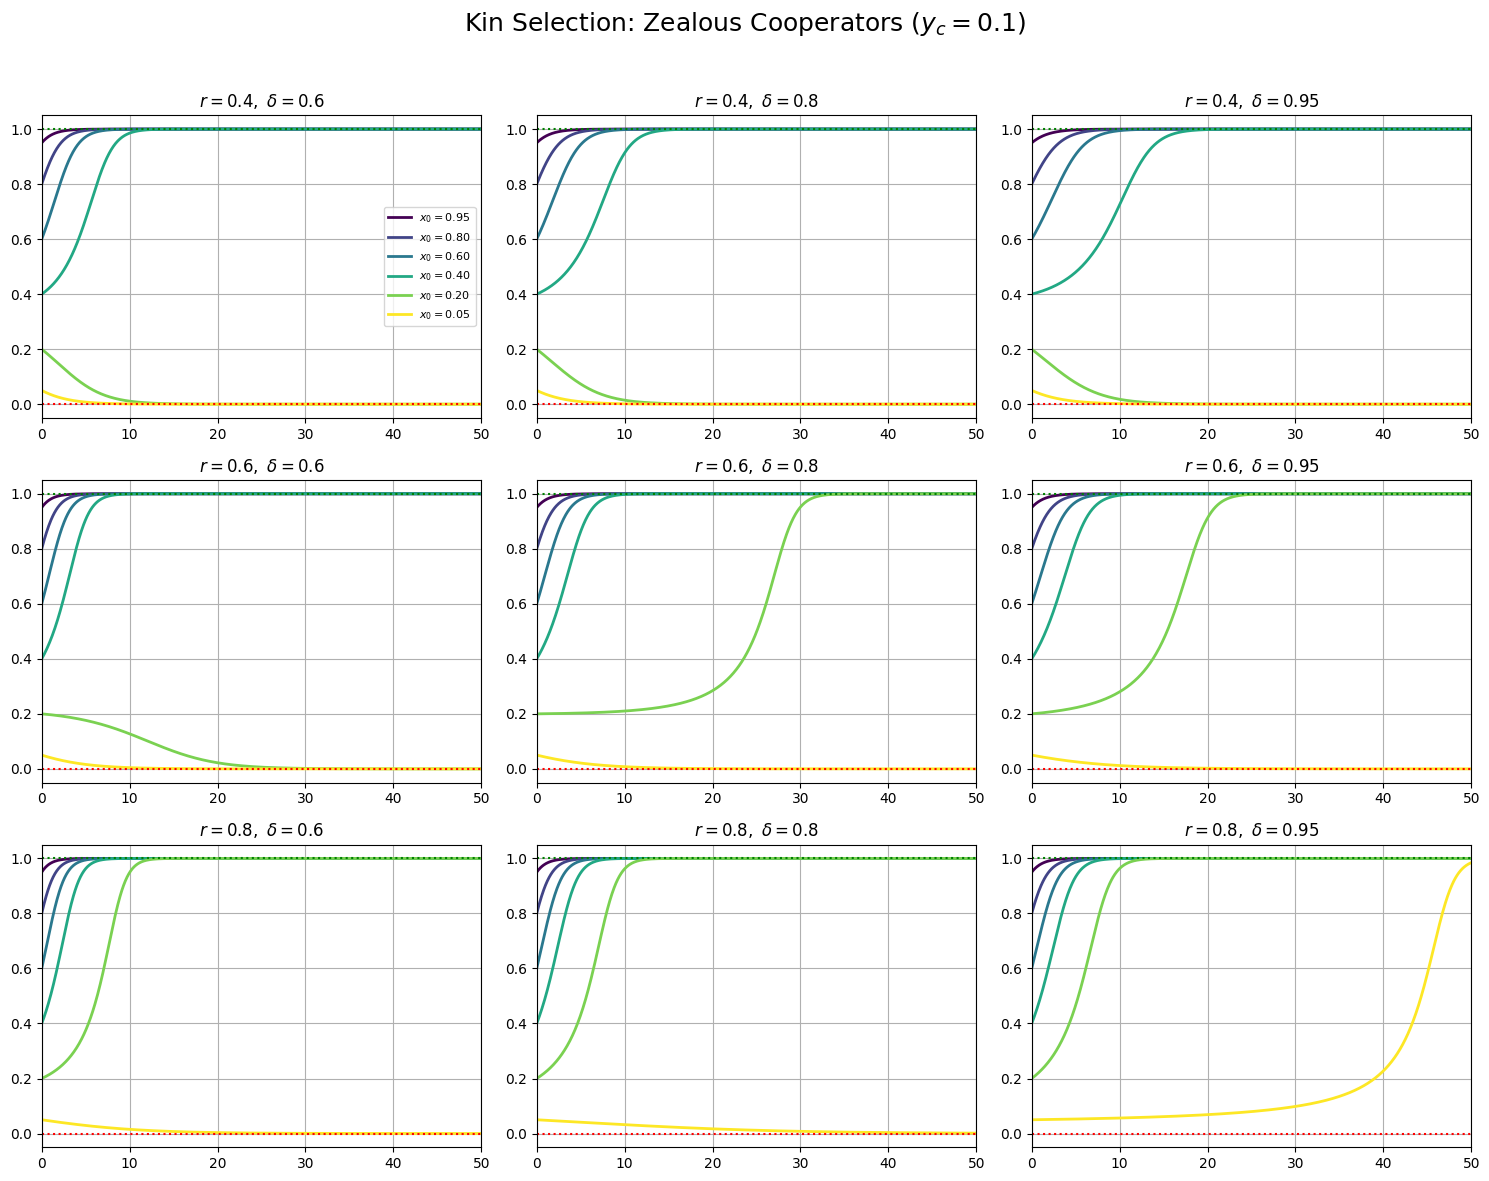

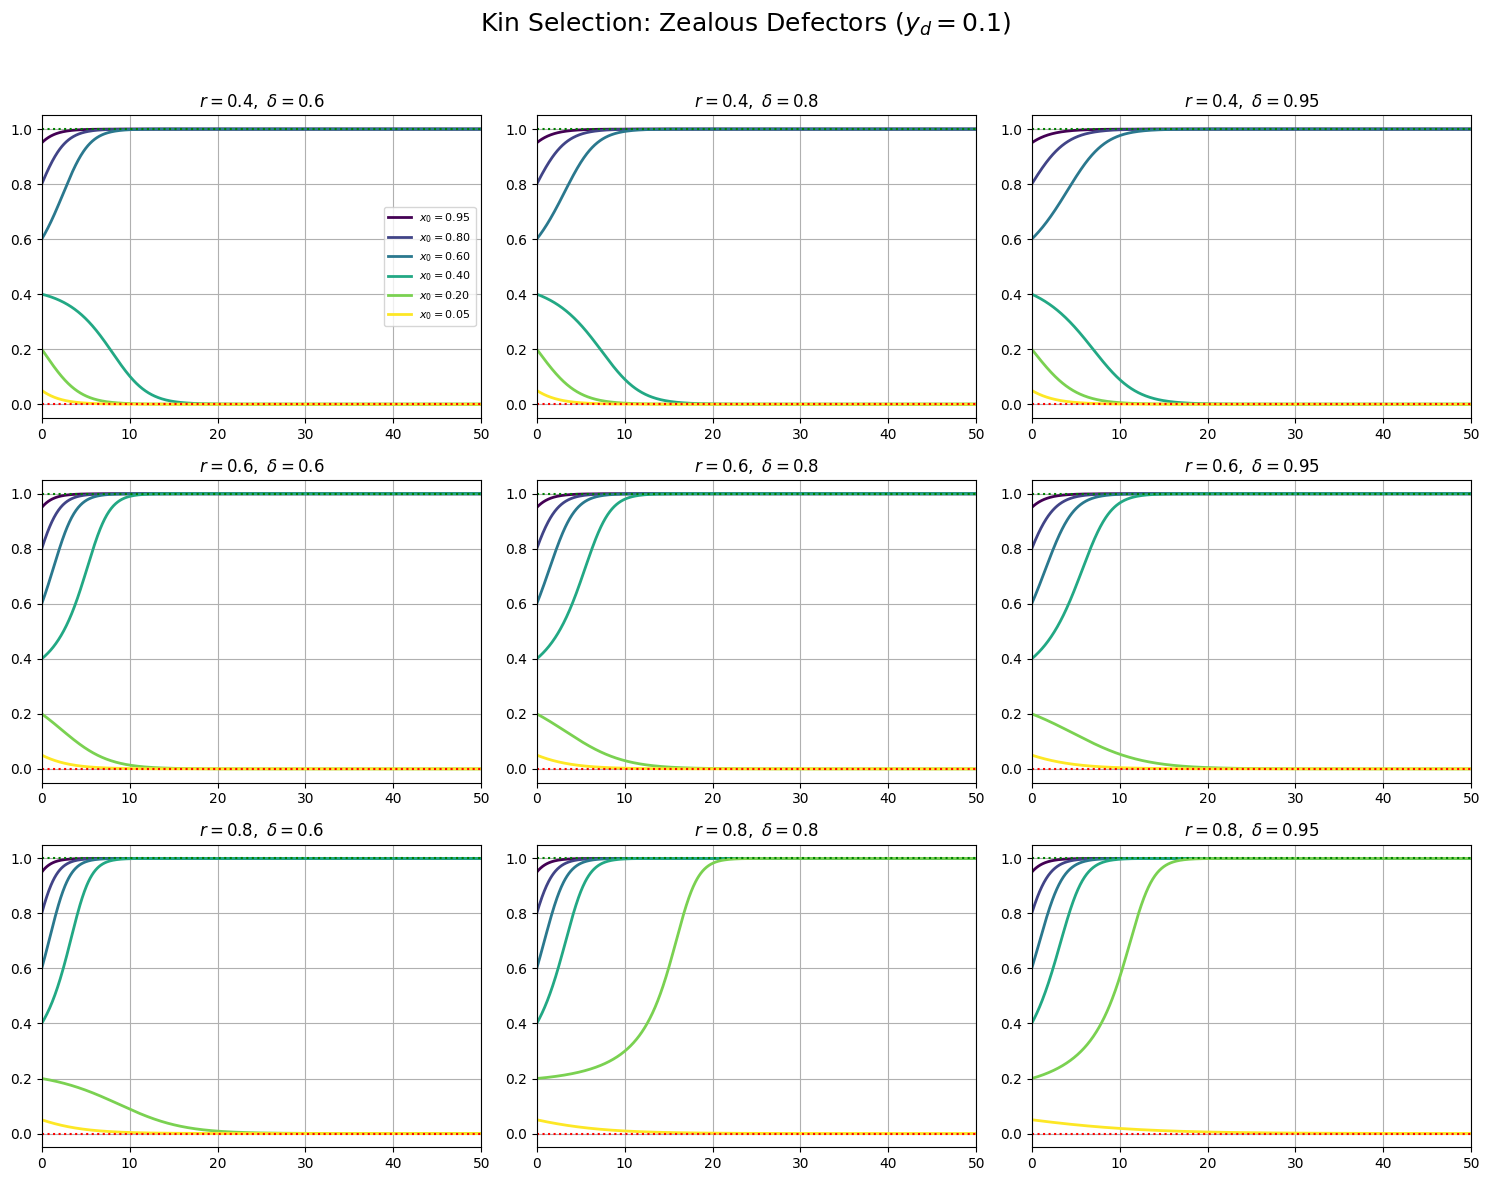

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================================
# STAG HUNT + KIN SELECTION
# STANDARD REPLICATOR DYNAMICS
#
# dx/dt = x(1-x)(πC-πD)
# ==========================================================

# ---------------- PARAMETERS ----------------
r_values = [0.4, 0.6, 0.8]
delta_values = [0.6, 0.8, 0.95]

yc = 0.10
yd = 0.10

x0_list = [0.95, 0.80, 0.60, 0.40, 0.20, 0.05]

tspan = (0,50)
t_eval = np.linspace(0,50,1000)

colors = plt.cm.viridis(np.linspace(0,1,len(x0_list)))

# ==========================================================
# ODE FUNCTIONS
# ==========================================================

def no_zealot(t,y,r,delta):

    x = y[0]

    R = 1
    S = (-1+r*delta)/(1+r)
    T = (delta-r)/(1+r)
    P = 0

    piC = x*R + (1-x)*S
    piD = x*T + (1-x)*P

    return [x*(1-x)*(piC-piD)]


def zealot_C(t,y,r,delta,yc):

    x = y[0]

    R = 1
    S = (-1+r*delta)/(1+r)
    T = (delta-r)/(1+r)
    P = 0

    piC = ((x+yc)*R + (1-x)*S)/(1+yc)
    piD = ((x+yc)*T + (1-x)*P)/(1+yc)

    return [x*(1-x)*(piC-piD)]


def zealot_D(t,y,r,delta,yd):

    x = y[0]

    R = 1
    S = (-1+r*delta)/(1+r)
    T = (delta-r)/(1+r)
    P = 0

    piC = (x*R + (1-x+yd)*S)/(1+yd)
    piD = (x*T + (1-x+yd)*P)/(1+yd)

    return [x*(1-x)*(piC-piD)]

# ==========================================================
# NO ZEALOTS
# ==========================================================

fig1, axes = plt.subplots(3,3,figsize=(15,12))
fig1.suptitle("Kin Selection: No Zealots",fontsize=18)

for i,r in enumerate(r_values):

    for j,delta in enumerate(delta_values):

        ax=axes[i,j]

        for k,x0 in enumerate(x0_list):

            sol=solve_ivp(
                no_zealot,
                tspan,
                [x0],
                args=(r,delta),
                t_eval=t_eval,
                rtol=1e-9,
                atol=1e-12
            )

            ax.plot(sol.t,sol.y[0],
                    color=colors[k],
                    lw=2,
                    label=f"$x_0={x0:.2f}$")

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$r={r},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.grid(True)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])

# ==========================================================
# ZEALOUS COOPERATORS
# ==========================================================

fig2, axes = plt.subplots(3,3,figsize=(15,12))
fig2.suptitle(
    f"Kin Selection: Zealous Cooperators ($y_c={yc}$)",
    fontsize=18
)

for i,r in enumerate(r_values):

    for j,delta in enumerate(delta_values):

        ax=axes[i,j]

        for k,x0 in enumerate(x0_list):

            sol=solve_ivp(
                zealot_C,
                tspan,
                [x0],
                args=(r,delta,yc),
                t_eval=t_eval,
                rtol=1e-9,
                atol=1e-12
            )

            ax.plot(sol.t,sol.y[0],
                    color=colors[k],
                    lw=2,
                    label=f"$x_0={x0:.2f}$")

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$r={r},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.grid(True)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])

# ==========================================================
# ZEALOUS DEFECTORS
# ==========================================================

fig3, axes = plt.subplots(3,3,figsize=(15,12))
fig3.suptitle(
    f"Kin Selection: Zealous Defectors ($y_d={yd}$)",
    fontsize=18
)

for i,r in enumerate(r_values):

    for j,delta in enumerate(delta_values):

        ax=axes[i,j]

        for k,x0 in enumerate(x0_list):

            sol=solve_ivp(
                zealot_D,
                tspan,
                [x0],
                args=(r,delta,yd),
                t_eval=t_eval,
                rtol=1e-9,
                atol=1e-12
            )

            ax.plot(sol.t,sol.y[0],
                    color=colors[k],
                    lw=2,
                    label=f"$x_0={x0:.2f}$")

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$r={r},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.grid(True)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

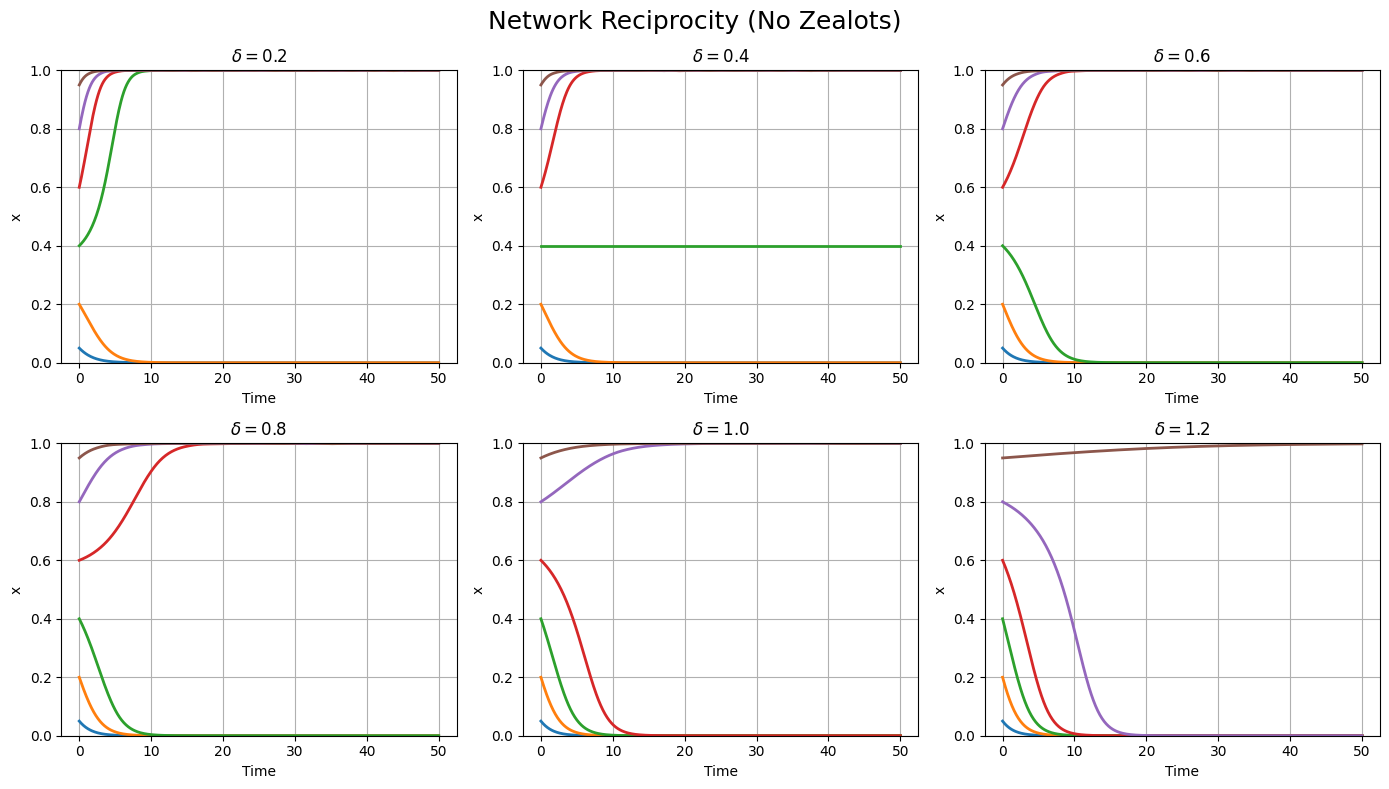

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================
# PARAMETERS
# ============================================

delta_values = [0.2,0.4,0.6,0.8,1.0,1.2]

k = 4                      # Degree of the network

t_span = (0,50)
t_eval = np.linspace(0,50,500)

initial_conditions = [0.05,0.2,0.4,0.6,0.8,0.95]

fig,axs = plt.subplots(2,3,figsize=(14,8))

for n,delta in enumerate(delta_values):

    ax = axs[n//3,n%3]

    h = (k-delta)/((k+1)*(k-2))

    R = 1
    S = -1 + h
    T = delta - h
    P = 0

    def network(t,x):

        x = x[0]

        piC = x*R + (1-x)*S
        piD = x*T + (1-x)*P

        dx = x*(1-x)*(piC-piD)

        return [dx]

    for x0 in initial_conditions:

        sol = solve_ivp(network,
                        t_span,
                        [x0],
                        t_eval=t_eval)

        ax.plot(sol.t,sol.y[0],lw=2)

    ax.set_title(r'$\delta={}$'.format(delta))
    ax.set_xlabel("Time")
    ax.set_ylabel("x")
    ax.set_ylim(0,1)
    ax.grid(True)

plt.suptitle("Network Reciprocity (No Zealots)",fontsize=18)

plt.tight_layout()
plt.show()

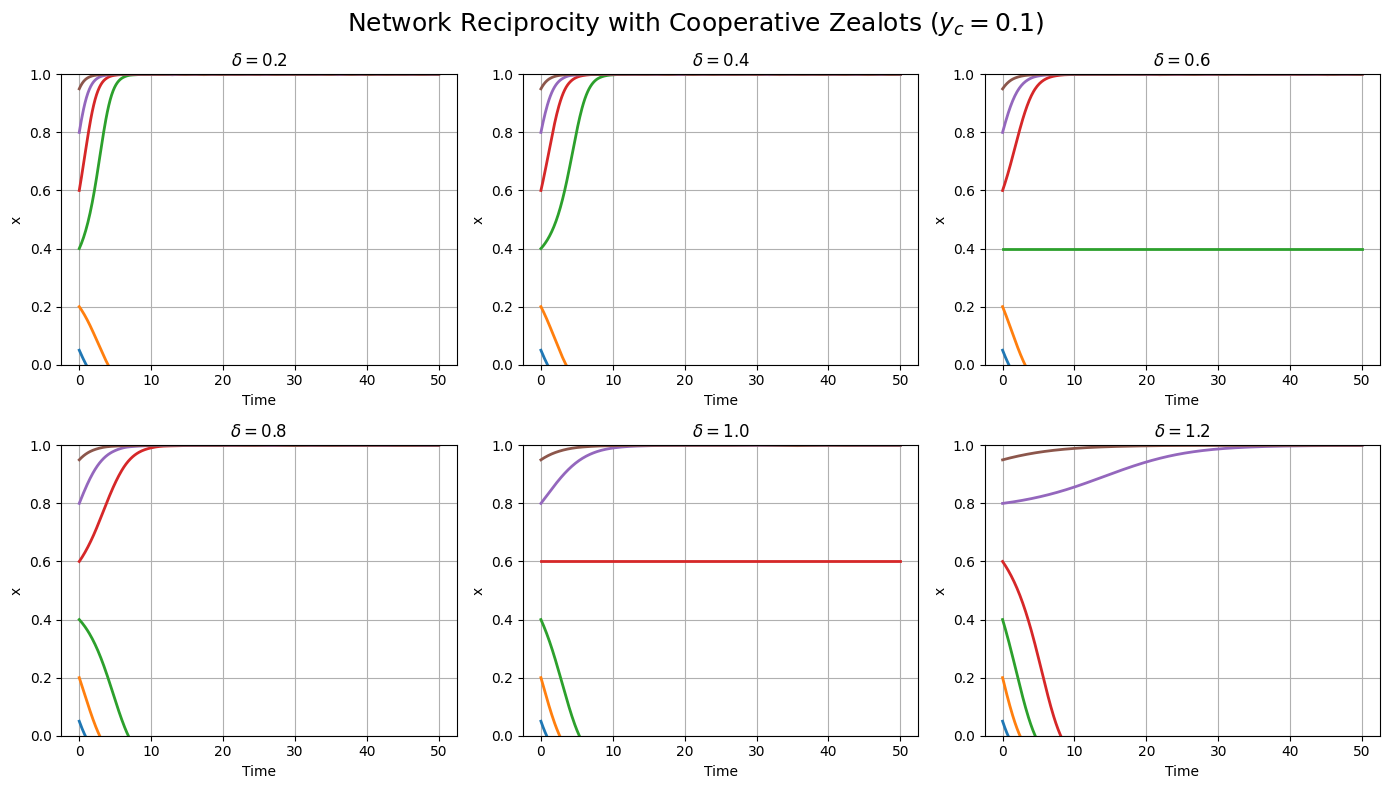

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================
# PARAMETERS
# ============================================

delta_values = [0.2,0.4,0.6,0.8,1.0,1.2]

k = 4
yc = 0.1

t_span = (0,50)
t_eval = np.linspace(0,50,500)

initial_conditions = [0.05,0.2,0.4,0.6,0.8,0.95]

fig,axs = plt.subplots(2,3,figsize=(14,8))

for n,delta in enumerate(delta_values):

    ax = axs[n//3,n%3]

    h = (k-delta)/((k+1)*(k-2))

    R = 1
    S = -1 + h
    T = delta - h
    P = 0

    def network_zealot(t,x):

        x = x[0]

        piC = ((x+yc)*R + (1-x)*S)/(1+yc)
        piD = ((x+yc)*T + (1-x)*P)/(1+yc)

        dx = ((x+yc)*piC*(1-x)
              -(1-x)*piD*x)

        return [dx]

    for x0 in initial_conditions:

        sol = solve_ivp(network_zealot,
                        t_span,
                        [x0],
                        t_eval=t_eval)

        ax.plot(sol.t,sol.y[0],lw=2)

    ax.set_title(r'$\delta={}$'.format(delta))
    ax.set_xlabel("Time")
    ax.set_ylabel("x")
    ax.set_ylim(0,1)
    ax.grid(True)

plt.suptitle("Network Reciprocity with Cooperative Zealots ($y_c=0.1$)",fontsize=18)

plt.tight_layout()
plt.show()

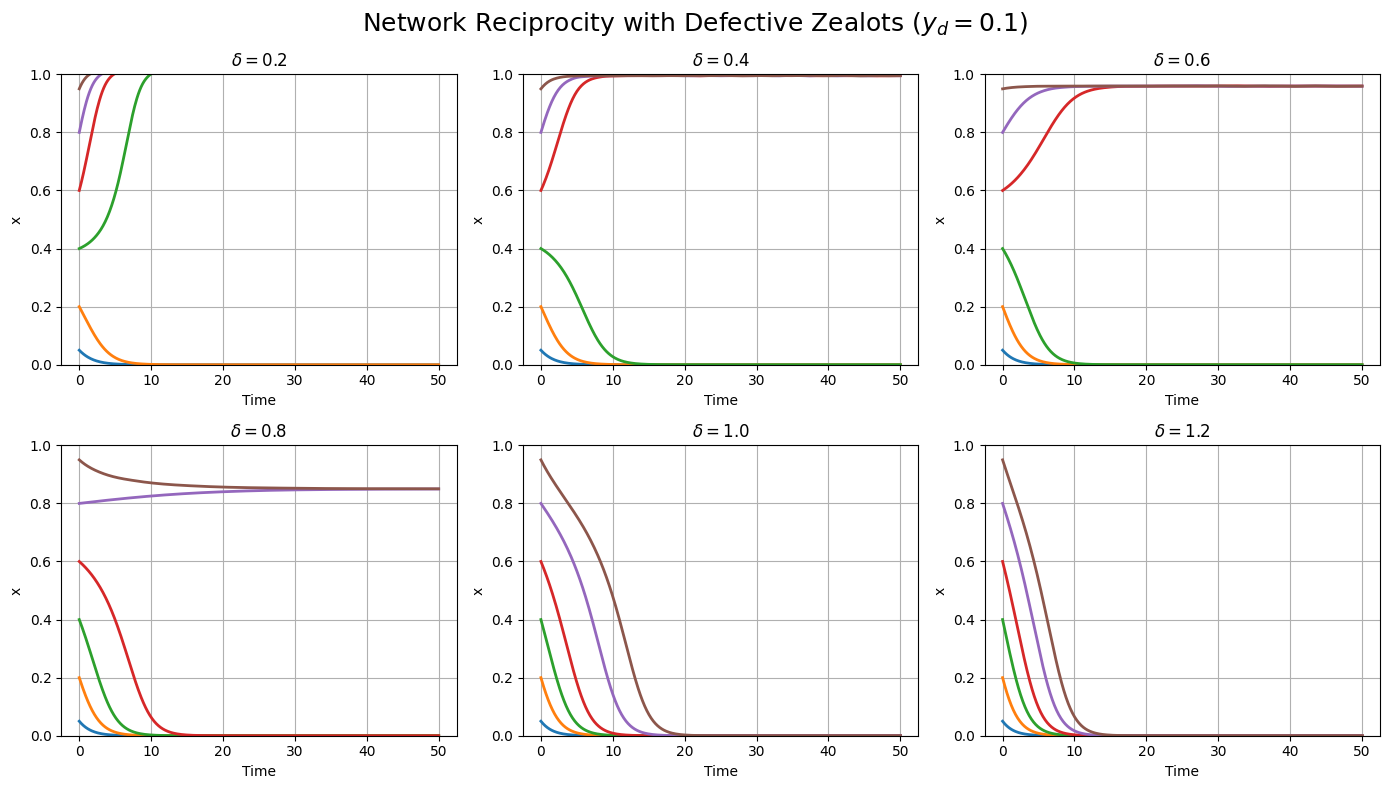

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================
# PARAMETERS
# ============================================

delta_values = [0.2,0.4,0.6,0.8,1.0,1.2]

k = 4
yd = 0.1

t_span = (0,50)
t_eval = np.linspace(0,50,500)

initial_conditions = [0.05,0.2,0.4,0.6,0.8,0.95]

fig,axs = plt.subplots(2,3,figsize=(14,8))

for n,delta in enumerate(delta_values):

    ax = axs[n//3,n%3]

    h = (k-delta)/((k+1)*(k-2))

    R = 1
    S = -1 + h
    T = delta - h
    P = 0

    def network_defector(t,x):

        x = x[0]

        piC = (x*R + (1-x+yd)*S)/(1+yd)
        piD = (x*T + (1-x+yd)*P)/(1+yd)

        dx = (x*piC*(1-x)
              -(1-x+yd)*piD*x)

        return [dx]

    for x0 in initial_conditions:

        sol = solve_ivp(network_defector,
                        t_span,
                        [x0],
                        t_eval=t_eval)

        ax.plot(sol.t,sol.y[0],lw=2)

    ax.set_title(r'$\delta={}$'.format(delta))
    ax.set_xlabel("Time")
    ax.set_ylabel("x")
    ax.set_ylim(0,1)
    ax.grid(True)

plt.suptitle("Network Reciprocity with Defective Zealots ($y_d=0.1$)",fontsize=18)

plt.tight_layout()
plt.show()